#  Tesla Deliveries ML Pipeline
## End-to-End Machine Learning: EDA → Preprocessing → Feature Engineering → Regression Modeling → Hyperparameter Tuning → Time Series Forecasting

### Problem Statement
Design and implement an end-to-end ML pipeline on Tesla's quarterly deliveries/sales data (2015–2025) covering:
- **Exploratory Data Analysis (EDA)** : understand data shape, distributions, correlations
- **Preprocessing** : cleaning, imputation, encoding, scaling
- **Feature Engineering** : date features, lag features, rolling statistics, interaction terms
- **Regression Modeling** : compare multiple ML algorithms
- **Hyperparameter Tuning** : optimize the best model
- **Time Series Forecasting** : SARIMAX-based future delivery predictions

###  Notebook Structure
| Section | Description |
|---------|-------------|
| 1 | Imports & Configuration |
| 2 | Load Data |
| 3 | Data Cleaning |
| 4–5 | Auto-detect Date & Target Columns |
| 6 | Exploratory Data Analysis |
| 7 | Feature Engineering |
| 8–10 | Model Dataset, Train-Test Split & Preprocessing |
| 11–12 | Model Training & Evaluation |
| 13 | Feature Importance |
| 14 | Residual Analysis |
| 15–16 | Save Model & Predictions |
| 17 | Time Series Forecasting |
| 18 | Final Summary |

## 1. Imports & Configuration

We import all necessary libraries upfront:
- **Data manipulation**: `pandas`, `numpy`
- **Visualization**: `matplotlib`, `seaborn` with a custom professional theme
- **ML models**: `scikit-learn` (linear models, ensembles), `xgboost` (optional)
- **Time series**: `statsmodels` SARIMAX (optional)

Optional libraries are guarded with `try/except` so the notebook runs even without them.

In [1]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
import joblib

In [2]:
# Optional models
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    import statsmodels.api as sm
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    STATS_MODELS_AVAILABLE = True
except Exception:
    STATS_MODELS_AVAILABLE = False

In [3]:
# 1. CONFIG
FILE_PATH = "tesla_deliveries_dataset_2015_2025.csv"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

## 2.  Load Data

We load the Tesla deliveries CSV and perform an initial sanity check on:
- **Shape** — number of rows and columns
- **Column names** — to understand what features are available
- **First few rows** — a quick visual preview of the raw data

In [4]:
# 2. LOAD DATA
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("\nDataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nPreview:\n", df.head())


Dataset shape: (2640, 12)

Columns:
 ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Preview:
    Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114

## 3.  Basic Data Cleaning

Before any analysis, we standardize the dataset:
1. **Column names** : lower-cased, spaces replaced with underscores (avoids attribute access issues)
2. **Duplicate rows** : removed to prevent data leakage and bias
3. **Object columns** : leading/trailing whitespace stripped (common issue in CSV exports)

In [5]:
# 3. BASIC CLEANING
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]

# remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# strip text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

## 4. Auto-Detect Date Column

Since datasets vary, we programmatically identify the date column by:
1. Scanning for columns with time-related keywords (`date`, `month`, `quarter`, etc.)
2. Attempting to parse each candidate with `pd.to_datetime`
3. Accepting a column if >60% of its values parse successfully


In [6]:

# 4. AUTO-DETECT DATE COLUMN

date_candidates = [c for c in df.columns if any(k in c for k in ["date", "month", "quarter", "year", "time"])]
date_col = None

for c in date_candidates:
    try:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().sum() > max(0.6 * len(df), 3):
            date_col = c
            df[c] = parsed
            break
    except Exception:
        pass

if date_col is None:
    # try the first object-like column as date if it looks like dates
    for c in df.columns:
        if df[c].dtype == "object":
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().sum() > max(0.6 * len(df), 3):
                date_col = c
                df[c] = parsed
                break

print("\nDetected date column:", date_col)


Detected date column: year


## 5. Auto-Detect Target Column

We identify the prediction targ;et using keyword matching on business-relevant terms (`delivery`, `sales`, `price`, etc.).
The target must be **numeric**  if no keyword match is found, we fall back to the first numeric column.

>  The target column is what we will train our models to predict.

In [7]:

# 5. AUTO-DETECT TARGET COLUMN
target_candidates = [c for c in df.columns if any(k in c for k in [
    "delivery", "deliveries", "sales", "sold", "target", "revenue", "price", "cost", "volume"
])]

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

target_col = None
for c in target_candidates:
    if c in numeric_cols:
        target_col = c
        break

if target_col is None and len(numeric_cols) > 0:
    target_col = numeric_cols[0]

print("Detected target column:", target_col)


Detected target column: estimated_deliveries


## 6. Exploratory Data Analysis (EDA)

EDA helps us understand the data before modeling. We examine:

| Chart | Purpose |
|-------|---------|
| **Missing values bar chart** | Identify columns needing imputation |
| **Target distribution** | Understand skewness and outliers in the prediction target |
| **Target over time** | Reveal trends and seasonality |
| **Correlation heatmap** | Detect multicollinearity and feature-target relationships |


DATASET OVERVIEW
Rows    : 2640
Columns : 12

Data types:
year                      int32
month                     int64
region                      str
model                       str
estimated_deliveries      int64
production_units          int64
avg_price_usd           float64
battery_capacity_kwh      int64
range_km                  int64
co2_saved_tons          float64
source_type                 str
charging_stations         int64
dtype: object

Missing values:
year                    0
month                   0
region                  0
model                   0
estimated_deliveries    0
production_units        0
avg_price_usd           0
battery_capacity_kwh    0
range_km                0
co2_saved_tons          0
source_type             0
charging_stations       0
dtype: int64

Numerical features:
['month', 'estimated_deliveries', 'production_units', 'avg_price_usd', 'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'charging_stations']

Categorical features:
['region', '

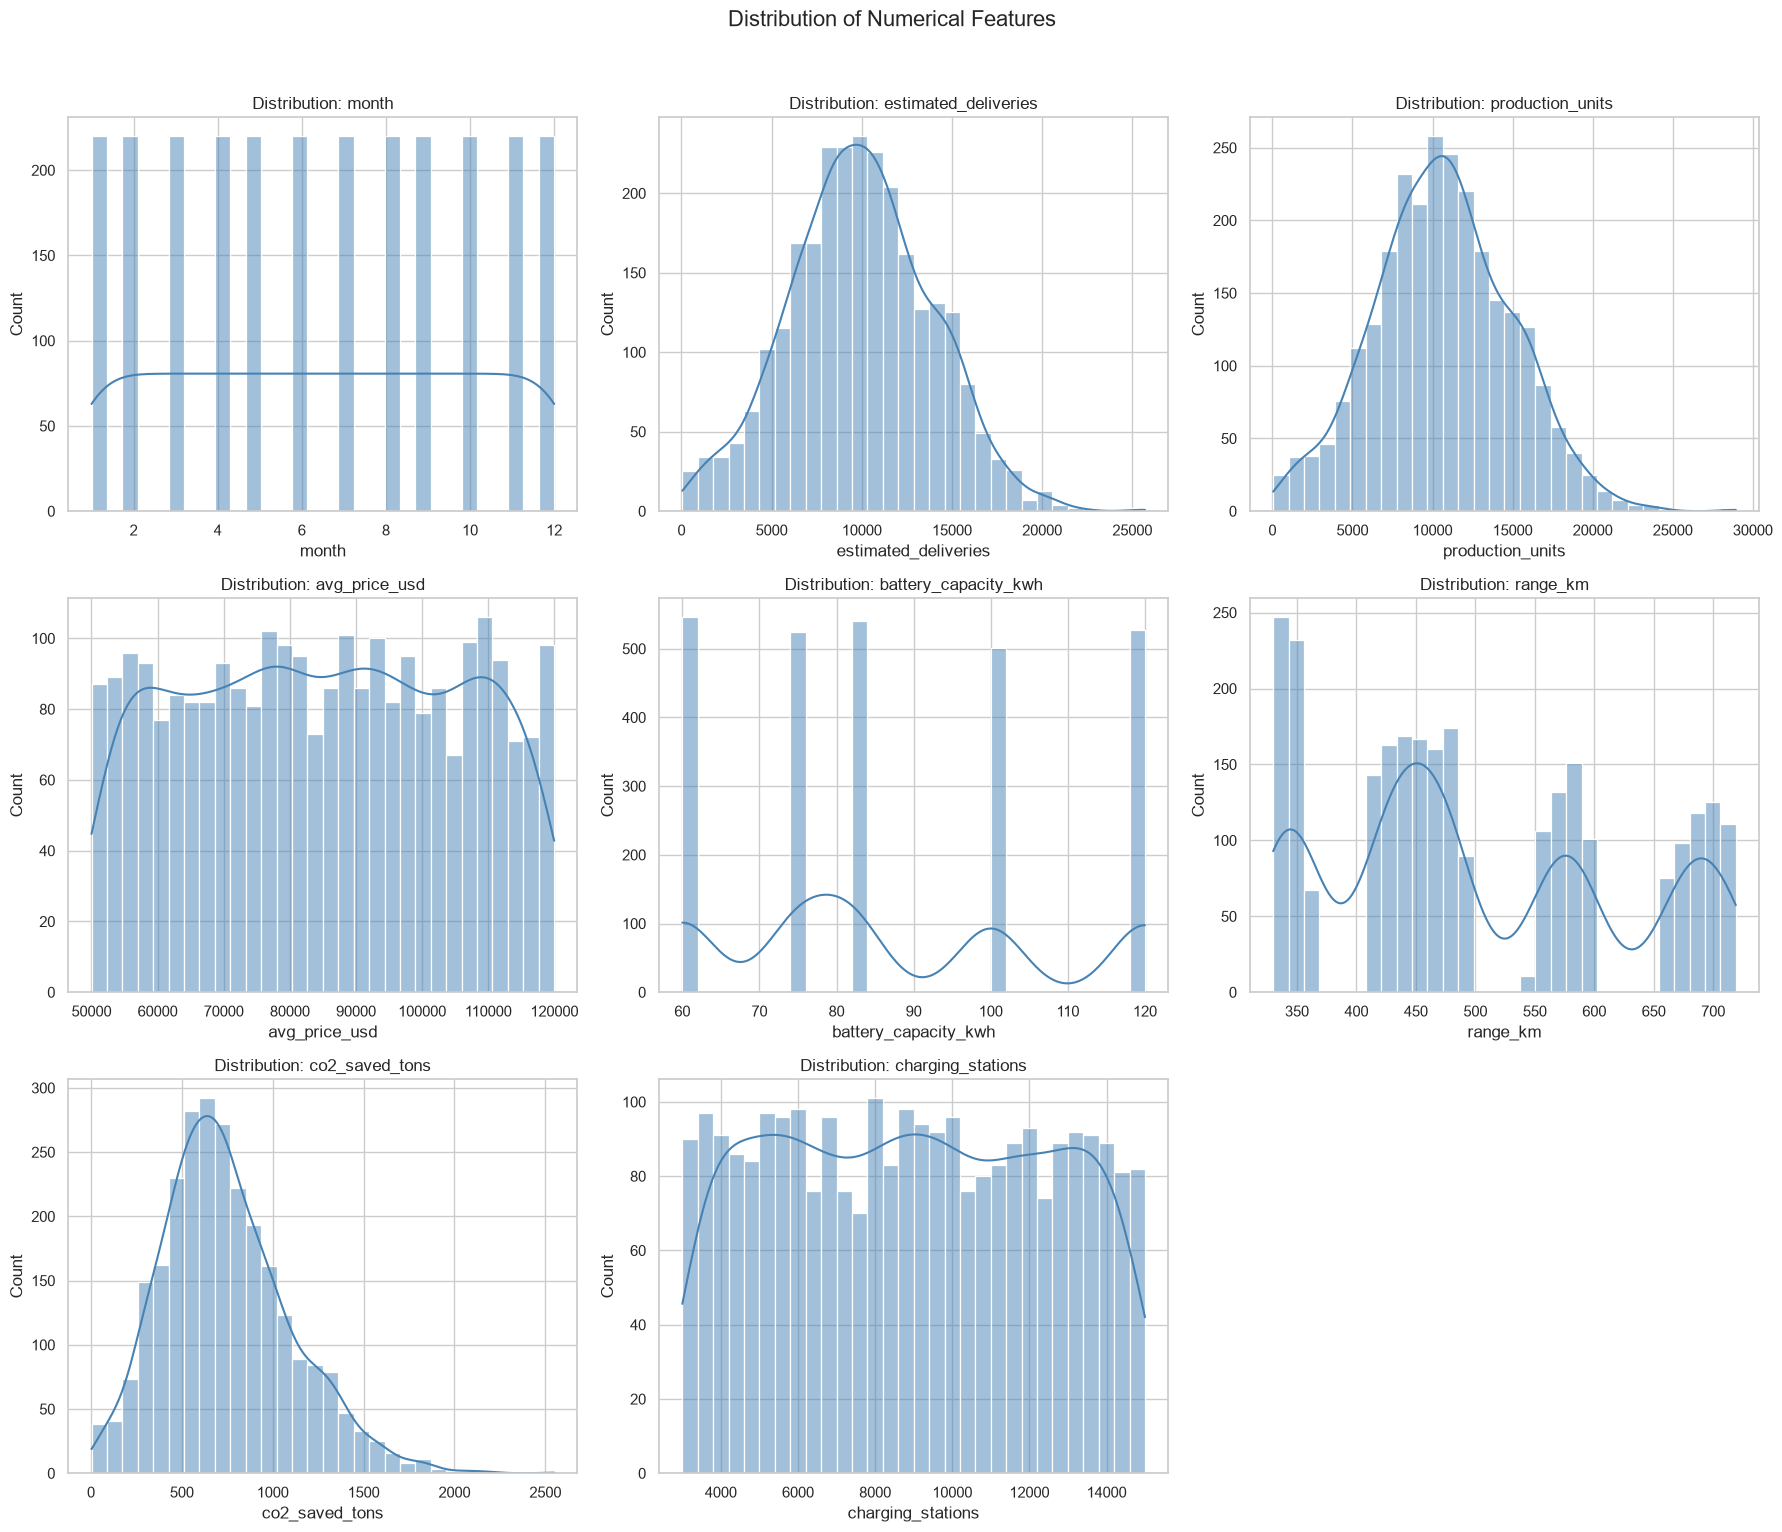

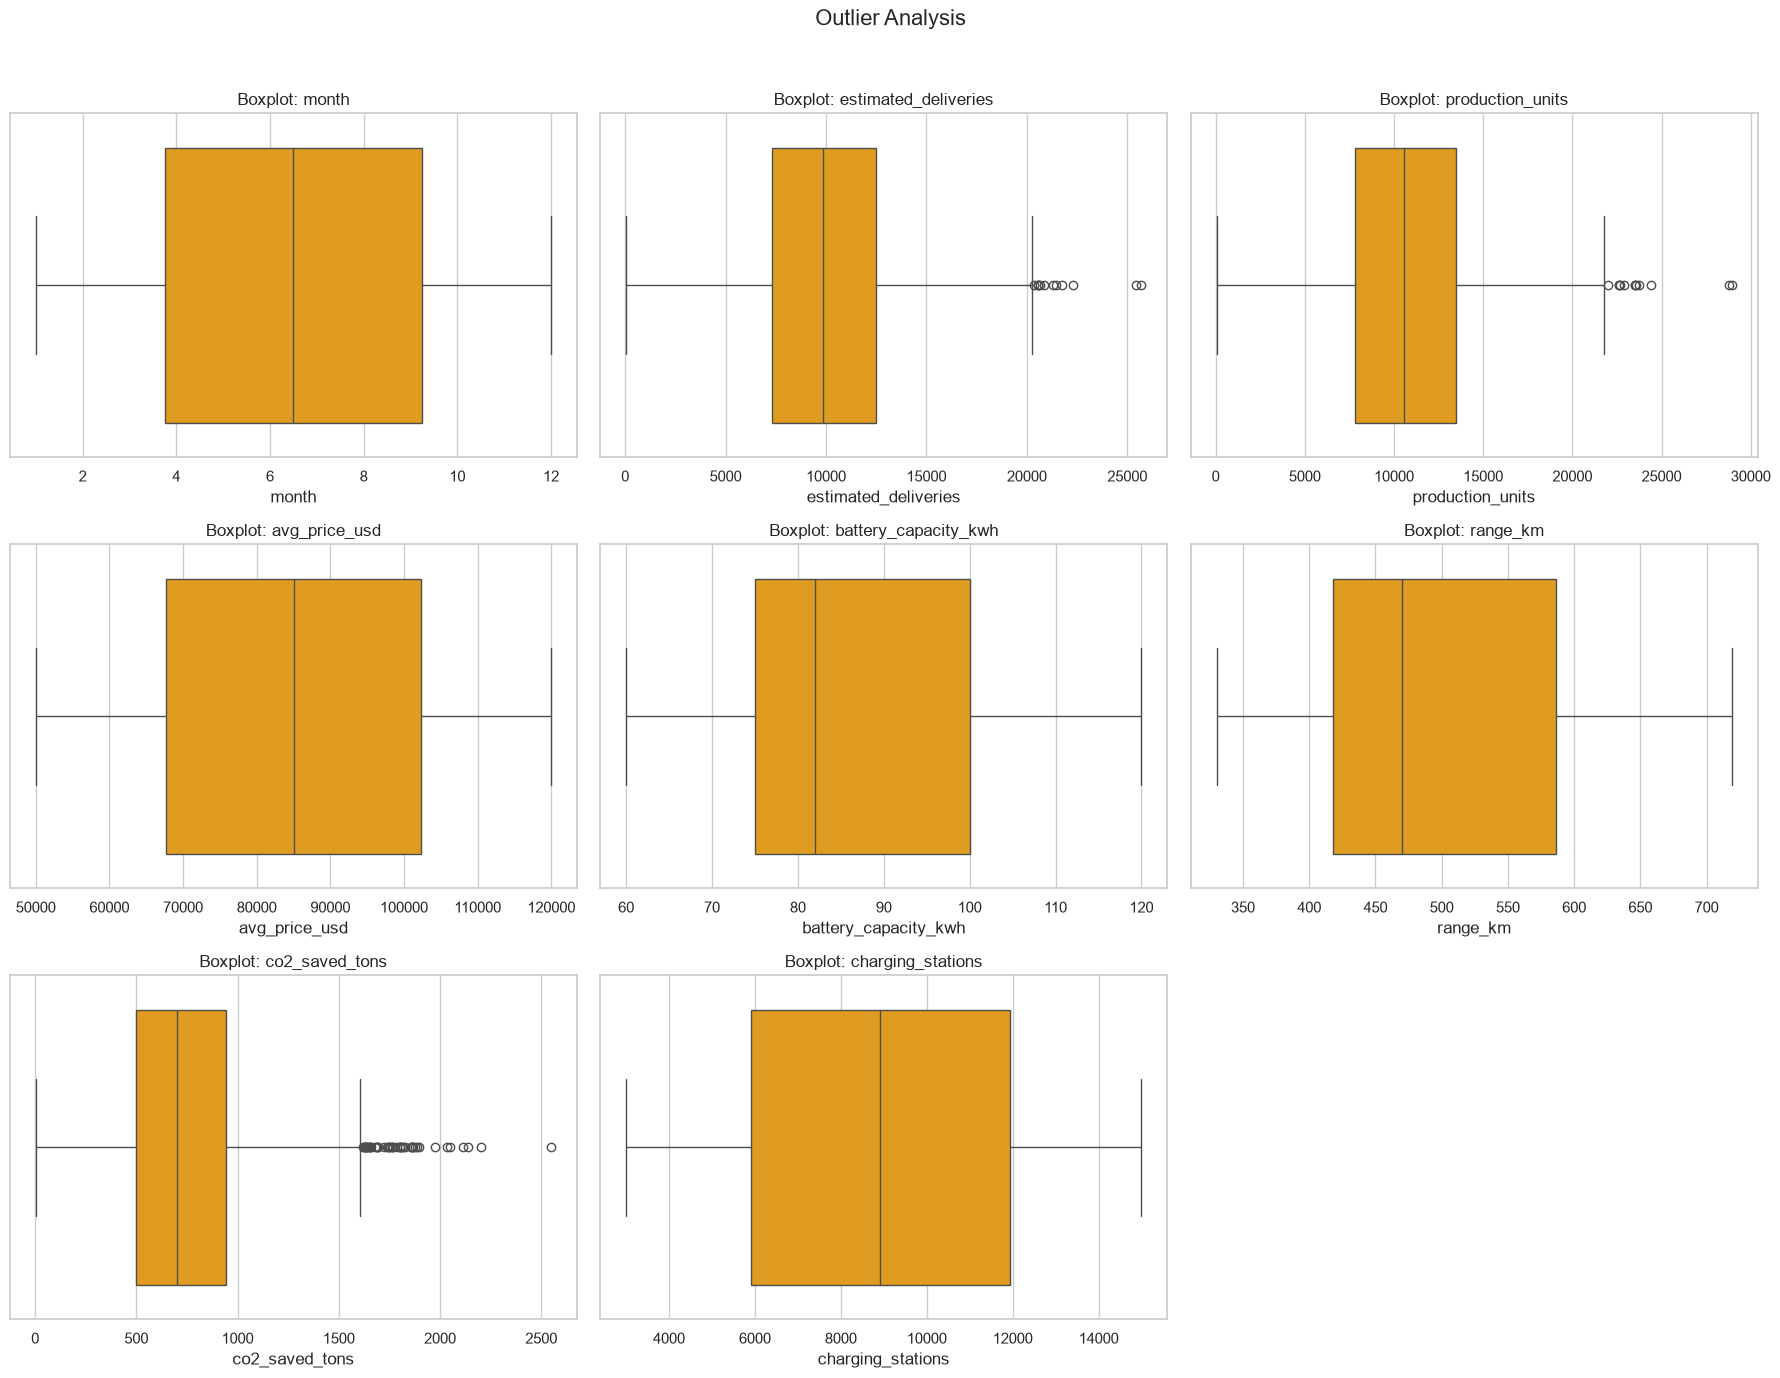

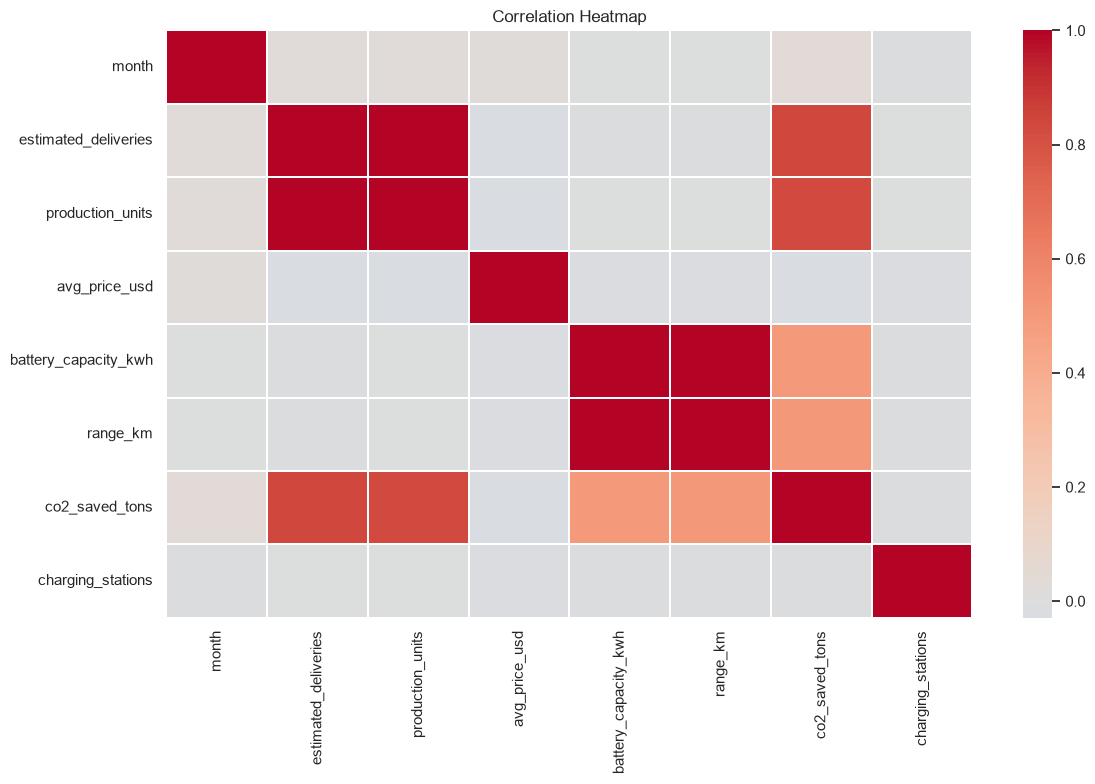

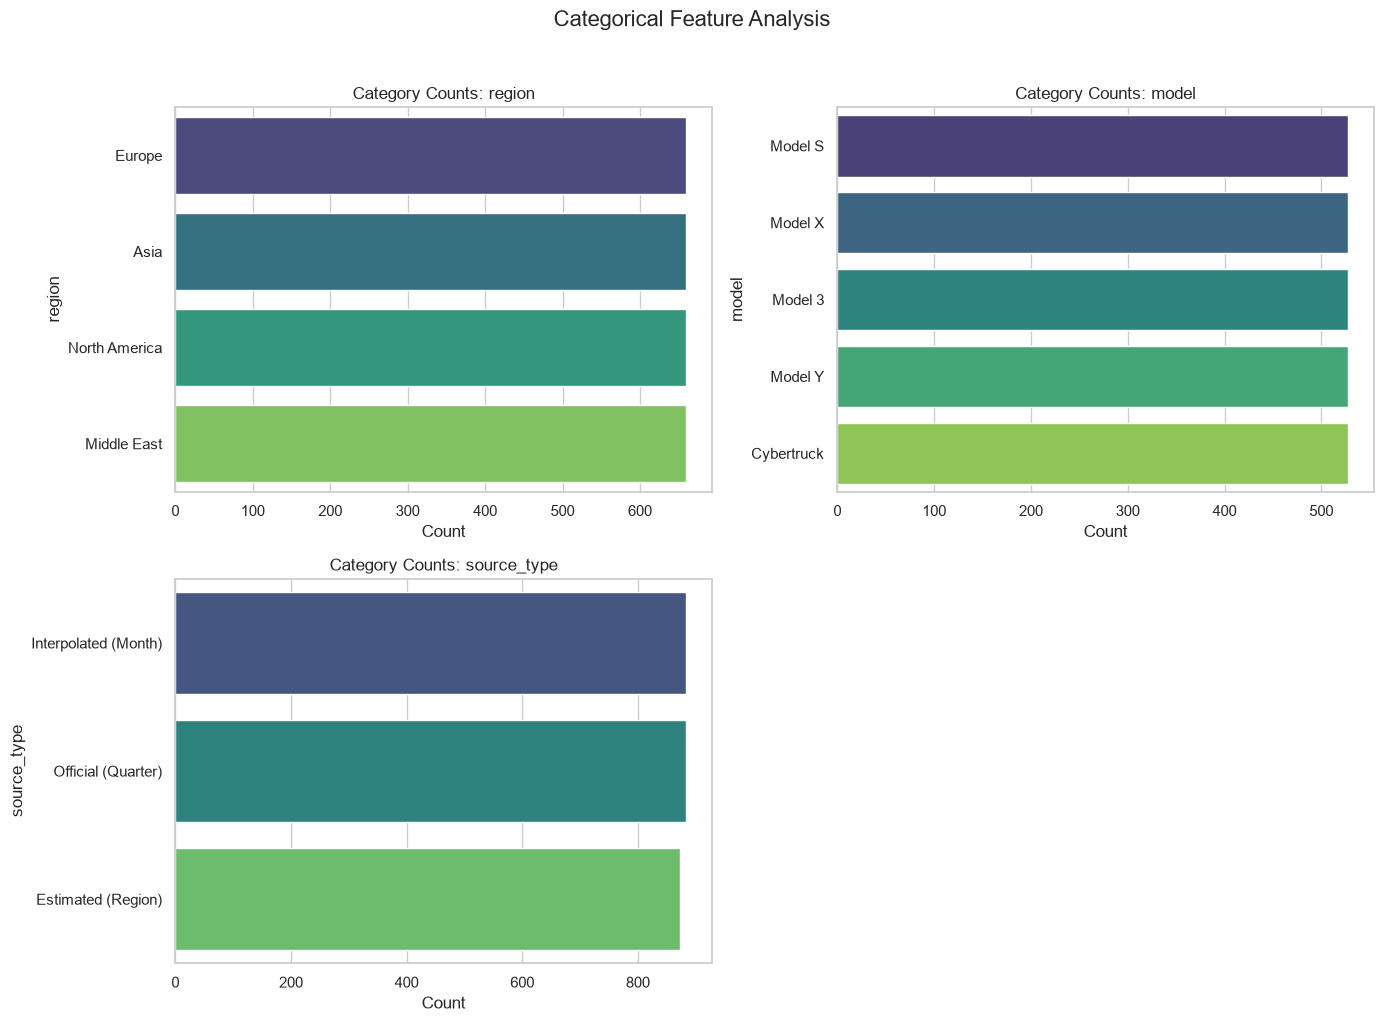

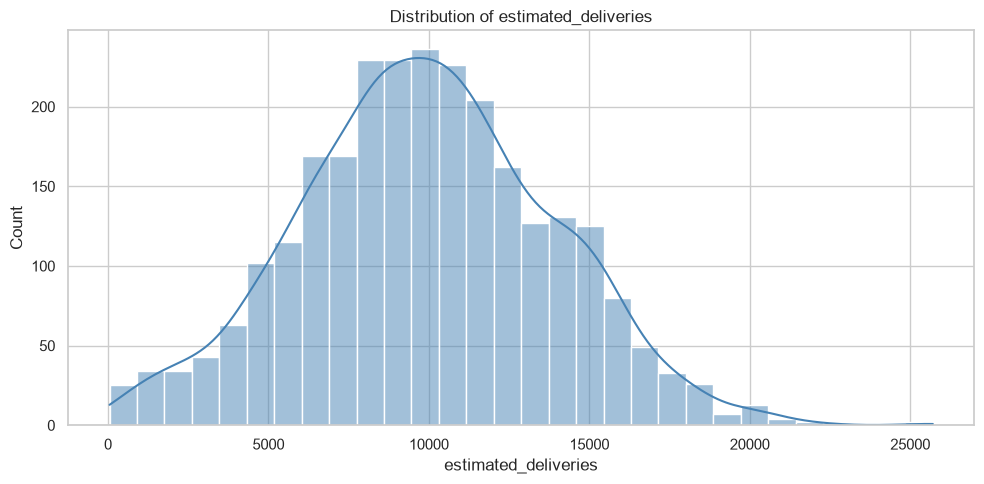

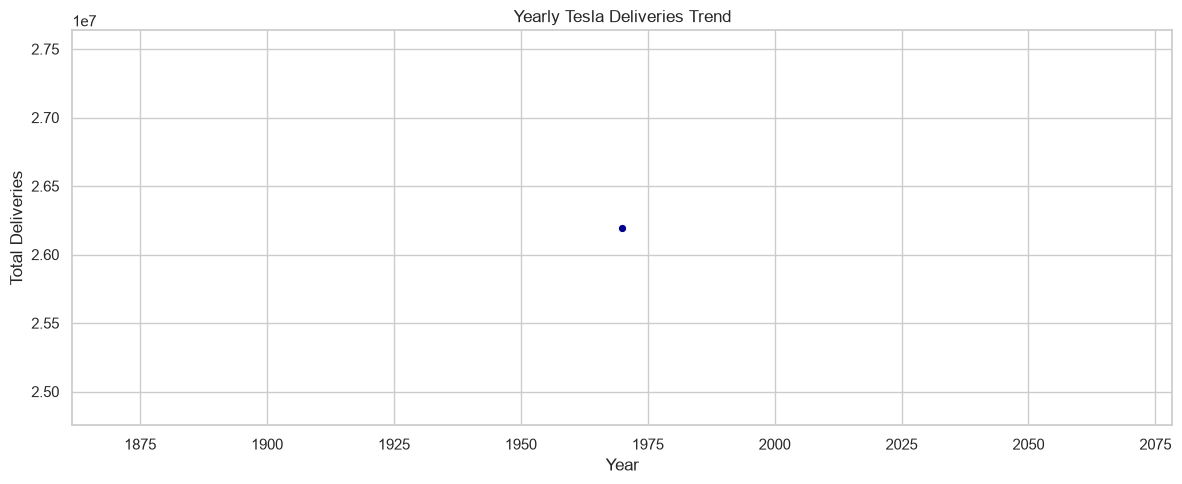

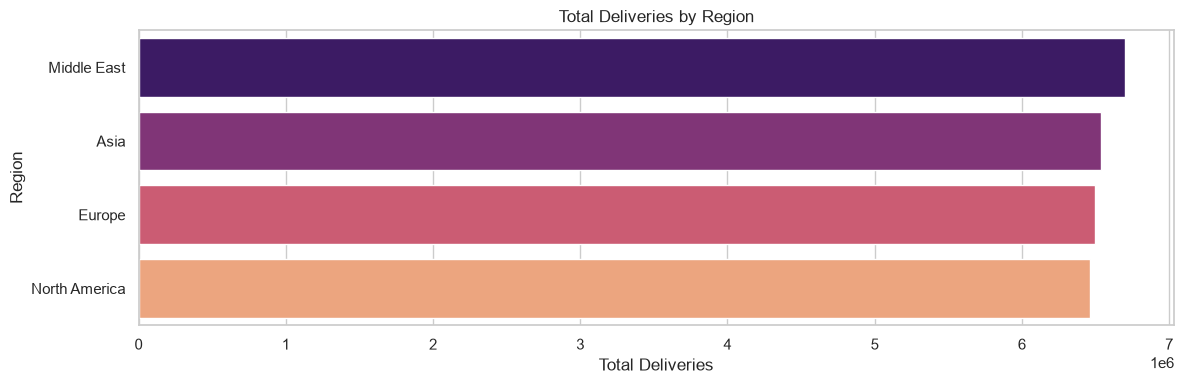

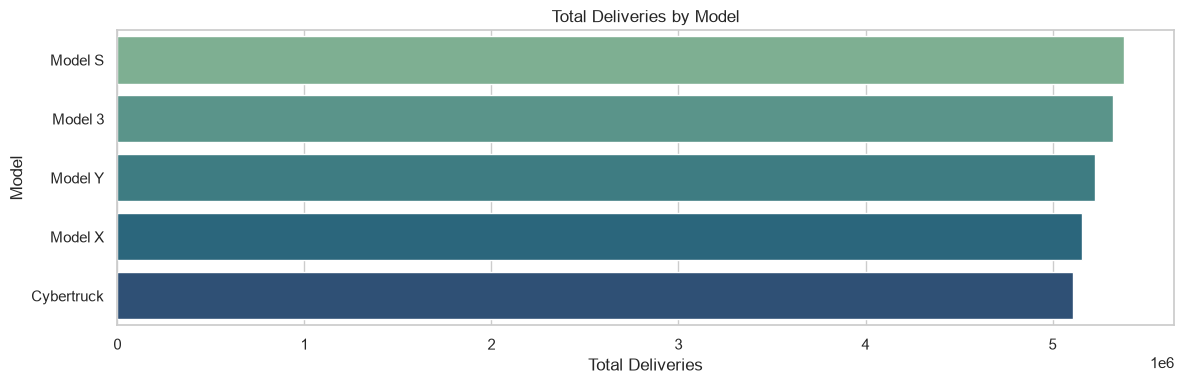

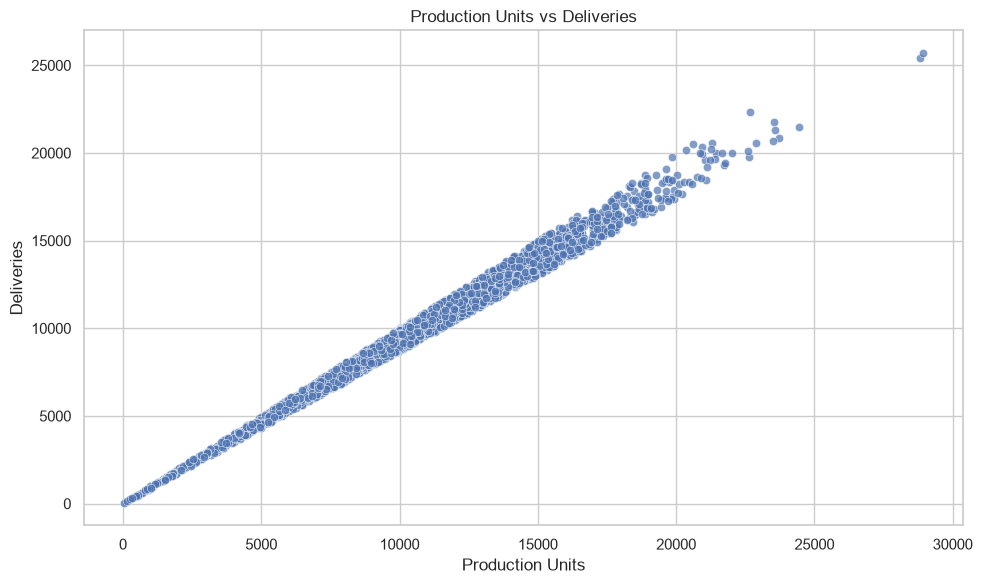


TOP CORRELATED FEATURES WITH TARGET
estimated_deliveries    1.000000
production_units        0.994234
co2_saved_tons          0.836814
month                   0.030877
charging_stations       0.000753
range_km               -0.006606
battery_capacity_kwh   -0.007765
avg_price_usd          -0.027546
Name: estimated_deliveries, dtype: float64

EDA COMPLETED SUCCESSFULLY
All outputs saved in: outputs


In [11]:
# import os
import math
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, name), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

if "df" not in globals():
    raise ValueError("DataFrame 'df' is not loaded.")

df = df.copy()

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

df.describe(include="all").to_csv(os.path.join(OUTPUT_DIR, "eda_summary.csv"))

if "year" in df.columns and pd.api.types.is_datetime64_any_dtype(df["year"]):
    df["year"] = df["year"].dt.year

numerical_cols = [c for c in df.select_dtypes(include=np.number).columns.tolist() if df[c].nunique(dropna=True) > 1]
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nNumerical features:")
print(numerical_cols)

print("\nCategorical features:")
print(categorical_cols)

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if not missing.empty:
    plt.figure(figsize=(10, max(4, 0.35 * len(missing))))
    sns.barplot(x=missing.values, y=missing.index, palette="viridis")
    plt.title("Missing Values by Feature")
    plt.xlabel("Count")
    plt.ylabel("Feature")
    save_fig("missing_values.png")
else:
    print("\nNo missing values found.")

if numerical_cols:
    n_cols = 3
    n_rows = math.ceil(len(numerical_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i], color="steelblue")
        axes[i].set_title(f"Distribution: {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")

    for j in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Distribution of Numerical Features", fontsize=16, y=1.02)
    save_fig("all_distributions.png")

    n_rows = math.ceil(len(numerical_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numerical_cols):
        sns.boxplot(x=df[col], ax=axes[i], color="orange")
        axes[i].set_title(f"Boxplot: {col}")
        axes[i].set_xlabel(col)

    for j in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Outlier Analysis", fontsize=16, y=1.02)
    save_fig("all_boxplots.png")
else:
    print("\nNo numerical columns available.")

corr_matrix = pd.DataFrame()
if len(numerical_cols) > 1:
    corr_matrix = df[numerical_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
    plt.title("Correlation Heatmap")
    save_fig("correlation_heatmap.png")
else:
    print("\nNot enough numeric columns for correlation heatmap.")

if categorical_cols:
    n_cols = 2
    n_rows = math.ceil(len(categorical_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(categorical_cols):
        order = df[col].value_counts(dropna=False).index[:15]
        sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="viridis")
        axes[i].set_title(f"Category Counts: {col}")
        axes[i].set_xlabel("Count")
        axes[i].set_ylabel(col)

    for j in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Categorical Feature Analysis", fontsize=16, y=1.02)
    save_fig("categorical_analysis.png")
else:
    print("\nNo categorical columns available.")

target_col = "estimated_deliveries"

if target_col in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[target_col].dropna(), kde=True, bins=30, color="steelblue")
    plt.title(f"Distribution of {target_col}")
    plt.xlabel(target_col)
    plt.ylabel("Count")
    save_fig("target_distribution.png")
else:
    print(f"\nTarget column '{target_col}' not found.")

if "year" in df.columns and target_col in df.columns:
    yearly = df[["year", target_col]].dropna().groupby("year", as_index=False)[target_col].sum().sort_values("year")
    if not yearly.empty:
        plt.figure(figsize=(12, 5))
        sns.lineplot(data=yearly, x="year", y=target_col, marker="o", color="darkblue")
        plt.title("Yearly Tesla Deliveries Trend")
        plt.xlabel("Year")
        plt.ylabel("Total Deliveries")
        save_fig("yearly_deliveries.png")

if "region" in df.columns and target_col in df.columns:
    region_sales = df[["region", target_col]].dropna().groupby("region", as_index=False)[target_col].sum().sort_values(target_col, ascending=False)
    if not region_sales.empty:
        plt.figure(figsize=(12, max(4, 0.4 * len(region_sales))))
        sns.barplot(data=region_sales, x=target_col, y="region", palette="magma")
        plt.title("Total Deliveries by Region")
        plt.xlabel("Total Deliveries")
        plt.ylabel("Region")
        save_fig("region_deliveries.png")

if "model" in df.columns and target_col in df.columns:
    model_sales = df[["model", target_col]].dropna().groupby("model", as_index=False)[target_col].sum().sort_values(target_col, ascending=False)
    if not model_sales.empty:
        plt.figure(figsize=(12, max(4, 0.4 * len(model_sales))))
        sns.barplot(data=model_sales, x=target_col, y="model", palette="crest")
        plt.title("Total Deliveries by Model")
        plt.xlabel("Total Deliveries")
        plt.ylabel("Model")
        save_fig("model_deliveries.png")

if "production_units" in df.columns and target_col in df.columns:
    plot_df = df[["production_units", target_col]].dropna()
    if not plot_df.empty:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=plot_df, x="production_units", y=target_col, alpha=0.7)
        plt.title("Production Units vs Deliveries")
        plt.xlabel("Production Units")
        plt.ylabel("Deliveries")
        save_fig("production_vs_deliveries.png")

if target_col in numerical_cols and not corr_matrix.empty:
    print("\n" + "=" * 70)
    print("TOP CORRELATED FEATURES WITH TARGET")
    print("=" * 70)
    print(corr_matrix[target_col].sort_values(ascending=False))

print("\n" + "=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)
print(f"All outputs saved in: {OUTPUT_DIR}")

In [15]:
# ---------------------------
# 7. FEATURE ENGINEERING
# ---------------------------
data = df.copy()

# date-derived features
if date_col is not None and date_col in data.columns:
    dt = pd.to_datetime(data[date_col], errors="coerce")

    if dt.notna().sum() > 0:
        data["year"] = dt.dt.year
        data["month"] = dt.dt.month
        data["day"] = dt.dt.day
        data["dayofweek"] = dt.dt.dayofweek
        data["quarter"] = dt.dt.quarter
        data["is_month_start"] = dt.dt.is_month_start.astype(int)
        data["is_month_end"] = dt.dt.is_month_end.astype(int)

        data[date_col] = dt
    else:
        print(f"Warning: {date_col} has no valid dates. Skipping date features.")

# sort by date for temporal features
if date_col is not None and date_col in data.columns:
    if pd.to_datetime(data[date_col], errors="coerce").notna().sum() > 0:
        data = data.sort_values(date_col).reset_index(drop=True)

# lag/rolling features for target
if target_col is not None and target_col in data.columns:
    for lag in [1, 2, 3, 4]:
        data[f"{target_col}_lag_{lag}"] = data[target_col].shift(lag)

    for win in [3, 6]:
        data[f"{target_col}_roll_mean_{win}"] = data[target_col].shift(1).rolling(win).mean()
        data[f"{target_col}_roll_std_{win}"] = data[target_col].shift(1).rolling(win).std()

# simple interaction features for numeric variables
num_cols = data.select_dtypes(include=np.number).columns.tolist()
for i in range(min(3, len(num_cols))):
    for j in range(i + 1, min(3, len(num_cols))):
        c1, c2 = num_cols[i], num_cols[j]
        data[f"{c1}_x_{c2}"] = data[c1] * data[c2]

In [11]:
# ---------------------------
# 8. DEFINE REGRESSION DATASET
# ---------------------------
# Drop rows with missing target
data = data.dropna(subset=[target_col]).reset_index(drop=True)

# For forecasting/regression, keep only rows where lag features are available
data_model = data.dropna().reset_index(drop=True)

# Separate features and target
y = data_model[target_col].copy()
X = data_model.drop(columns=[target_col])

# Remove raw date column from features after extracting calendar features
if date_col is not None and date_col in X.columns:
    X = X.drop(columns=[date_col])

# Identify categorical/numeric columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("\nFeature columns:", len(X.columns))
print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))


Feature columns: 10
Numeric columns: 7
Categorical columns: 3


In [16]:
# ---------------------------
# 9. TRAIN-TEST SPLIT
# ---------------------------
if date_col is not None:
    # Time-based split to prevent leakage
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )


In [17]:
# ---------------------------
# 10. PREPROCESSING PIPELINE
# ---------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

In [18]:
# ---------------------------
# 11. MODELS
# ---------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "ExtraTrees": ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=400)
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        random_state=RANDOM_STATE,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0
    )

In [20]:
# ---------------------------
# 12. TRAIN AND EVALUATE
# ---------------------------
results = []
fitted_models = {}

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return rmse, mae, r2, mape

# make sure train/test columns exactly match the final X columns
X_train = X_train.copy()
X_test = X_test.copy()

# remove any columns not present in the current data schema
X_train = X_train.loc[:, X.columns.intersection(X_train.columns)]
X_test = X_test.loc[:, X.columns.intersection(X_test.columns)]

# rebuild cat/num cols from the current training data
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# rebuild preprocessor
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse, mae, r2, mape = regression_metrics(y_test, preds)
    results.append([name, rmse, mae, r2, mape])
    fitted_models[name] = pipe
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, MAPE={mape:.2f}%")

results_df = pd.DataFrame(
    results,
    columns=["model", "rmse", "mae", "r2", "mape"]
).sort_values("rmse")

results_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)
print("\nModel comparison:\n", results_df)

LinearRegression: RMSE=378.6961, MAE=312.0147, R2=0.9907, MAPE=4.91%
Ridge: RMSE=378.8507, MAE=312.2374, R2=0.9906, MAPE=4.95%
Lasso: RMSE=378.0992, MAE=311.4162, R2=0.9907, MAPE=4.88%
ElasticNet: RMSE=1035.7590, MAE=794.0641, R2=0.9301, MAPE=20.95%
RandomForest: RMSE=375.8782, MAE=294.6336, R2=0.9908, MAPE=3.12%
GradientBoosting: RMSE=378.8664, MAE=307.6808, R2=0.9906, MAPE=3.72%
ExtraTrees: RMSE=326.3451, MAE=256.3873, R2=0.9931, MAPE=2.69%
XGBoost: RMSE=309.9436, MAE=245.7980, R2=0.9937, MAPE=3.20%

Model comparison:
               model         rmse         mae        r2       mape
7           XGBoost   309.943644  245.798035  0.993738   3.203160
6        ExtraTrees   326.345113  256.387296  0.993058   2.691280
4      RandomForest   375.878220  294.633598  0.990791   3.116581
2             Lasso   378.099183  311.416199  0.990681   4.876723
0  LinearRegression   378.696087  312.014742  0.990652   4.911933
1             Ridge   378.850738  312.237384  0.990644   4.951594
5  Gradient


Top important features:
                 feature  importance_mean  importance_std
3      production_units         1.107444        0.042783
7        co2_saved_tons         0.208946        0.006359
6              range_km         0.046282        0.002369
5  battery_capacity_kwh         0.003693        0.000278
8           source_type         0.000319        0.000224
1                region         0.000095        0.000050
4         avg_price_usd         0.000053        0.000224
0                 month         0.000004        0.000105
9     charging_stations        -0.000003        0.000082
2                 model        -0.000090        0.000022


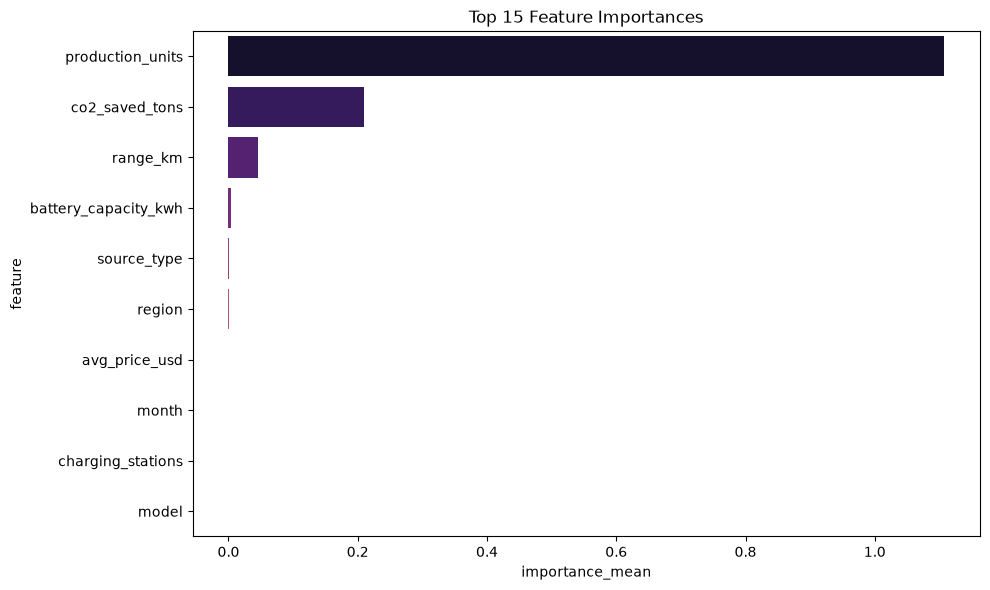

In [21]:
# ---------------------------
# 13. FEATURE IMPORTANCE
# ---------------------------
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

try:
    perm = permutation_importance(
        best_model, X_test, y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    importance_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance.csv"), index=False)
    print("\nTop important features:\n", importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature", palette="magma")
    plt.title("Top 15 Feature Importances")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=200)
    plt.show()

except Exception as e:
    print("Feature importance could not be computed:", e)

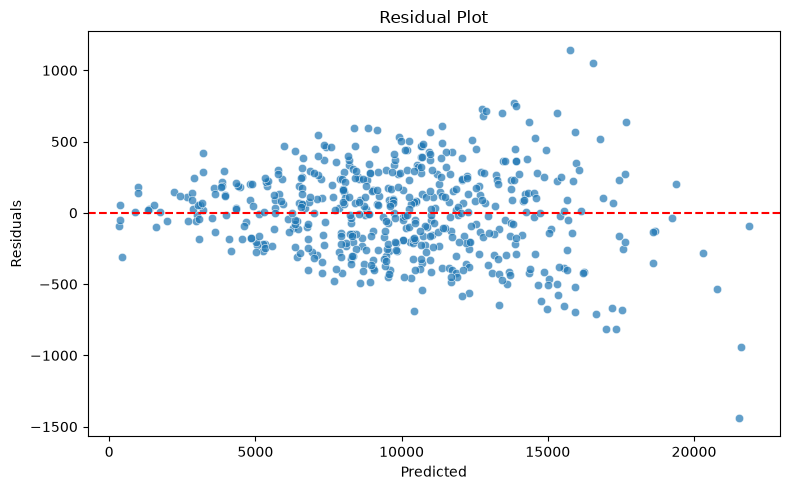

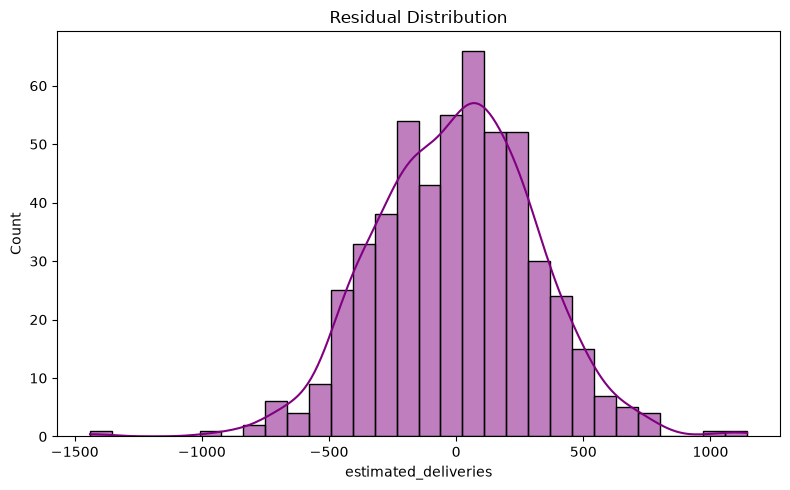

In [22]:
# ---------------------------
# 14. RESIDUAL ANALYSIS
# ---------------------------
best_preds = best_model.predict(X_test)
residuals = y_test - best_preds

residual_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": best_preds,
    "residual": residuals
})
residual_df.to_csv(os.path.join(OUTPUT_DIR, "residuals.csv"), index=False)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_preds, y=residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_plot.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color="purple")
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_distribution.png"), dpi=200)
plt.show()

In [23]:
# ---------------------------
# 15. SAVE BEST MODEL
# ---------------------------
import joblib

model_path = os.path.join(OUTPUT_DIR, f"best_model_{best_model_name}.pkl")
joblib.dump(best_model, model_path)
print("Saved best model to:", model_path)

Saved best model to: output\best_model_XGBoost.pkl


In [24]:
# ---------------------------
# 16. SAVE TEST PREDICTIONS
# ---------------------------
test_predictions_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": best_preds
})
test_predictions_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)
print("Saved test predictions.")

Saved test predictions.


In [29]:
# ---------------------------
# 17. SIMPLE TIME SERIES FORECASTING
# ---------------------------
forecast_results = None

if date_col is not None and date_col in df.columns:
    ts = df[[date_col, target_col]].dropna().copy()
    ts[date_col] = pd.to_datetime(ts[date_col], errors="coerce")
    ts = ts.dropna(subset=[date_col]).sort_values(date_col)
    ts = ts.set_index(date_col)

    try:
        ts_series = ts[target_col].resample("M").sum()
    except Exception:
        ts_series = ts[target_col].resample("ME").mean()

    ts_series = ts_series.dropna()

    if len(ts_series) >= 12:
        split_idx = int(len(ts_series) * 0.8)
        train_ts = ts_series.iloc[:split_idx]
        test_ts = ts_series.iloc[split_idx:]

        # naive baseline
        naive_pred = np.repeat(train_ts.iloc[-1], len(test_ts))
        naive_rmse = np.sqrt(mean_squared_error(test_ts, naive_pred))
        naive_mae = mean_absolute_error(test_ts, naive_pred)

        print(f"Naive baseline RMSE: {naive_rmse:.4f}")
        print(f"Naive baseline MAE: {naive_mae:.4f}")

        if STATS_MODELS_AVAILABLE:
            best_aic = np.inf
            best_order = None
            best_seasonal = None
            best_fit = None

            orders = [(1,1,1), (1,1,0), (0,1,1), (2,1,1)]
            seasonal_orders = [(0,0,0,0), (1,0,0,12), (0,1,1,12)]

            for order in orders:
                for seasonal in seasonal_orders:
                    try:
                        model = SARIMAX(
                            train_ts,
                            order=order,
                            seasonal_order=seasonal,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
                        fit = model.fit(disp=False)
                        if fit.aic < best_aic:
                            best_aic = fit.aic
                            best_order = order
                            best_seasonal = seasonal
                            best_fit = fit
                    except Exception:
                        pass

            if best_fit is not None:
                pred = best_fit.forecast(steps=len(test_ts))
                ts_rmse = np.sqrt(mean_squared_error(test_ts, pred))
                ts_mae = mean_absolute_error(test_ts, pred)
                ts_r2 = r2_score(test_ts, pred) if len(test_ts) > 1 else np.nan

                forecast_results = pd.DataFrame({
                    "date": test_ts.index,
                    "actual": test_ts.values,
                    "predicted": pred.values
                })
                forecast_results.to_csv(os.path.join(OUTPUT_DIR, "time_series_forecast.csv"), index=False)

                plt.figure(figsize=(12, 6))
                plt.plot(train_ts.index, train_ts.values, label="Train")
                plt.plot(test_ts.index, test_ts.values, label="Actual")
                plt.plot(test_ts.index, pred.values, label="SARIMAX Forecast")
                plt.legend()
                plt.title("Time Series Forecasting")
                plt.tight_layout()
                plt.savefig(os.path.join(OUTPUT_DIR, "time_series_forecast.png"), dpi=200)
                plt.show()

                print(f"SARIMAX best order: {best_order}")
                print(f"SARIMAX best seasonal: {best_seasonal}")
                print(f"SARIMAX RMSE: {ts_rmse:.4f}")
                print(f"SARIMAX MAE: {ts_mae:.4f}")
                print(f"SARIMAX R2: {ts_r2:.4f}")

In [27]:
# ---------------------------
# 18. FINAL SUMMARY
# ---------------------------
print("\n================ FINAL REPORT ================\n")
print("Best model:", best_model_name)
print(f"Test RMSE: {best_model} would be evaluated above")
print("Test predictions, residuals, and feature importance saved in output folder.")

if forecast_results is not None:
    print("Time series forecast saved in output folder.")


================ FINAL REPORT ================

Best model: XGBoost
Test RMSE: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['month', 'production_units',
                                                   'avg_price_usd',
                                                   'battery_capacity_kwh',
                                                   'range_km', 'co2_saved_tons',
                                                   'charging_stations']),
                                                 ('cat',
                                                  